
--- Running: Electricity Ablation (Window: 5) ---
Results -> MSE: 0.0054


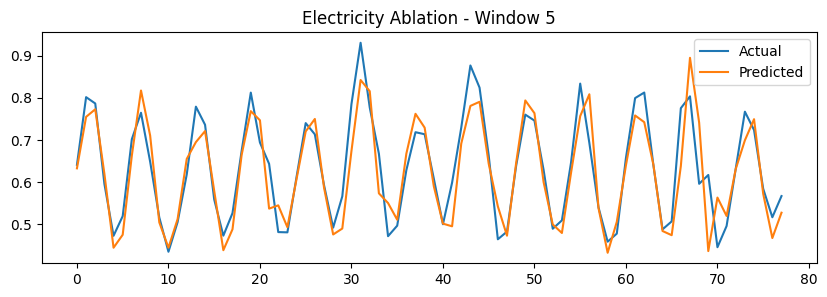


--- Running: Electricity Ablation (Window: 11) ---
Results -> MSE: 0.0049


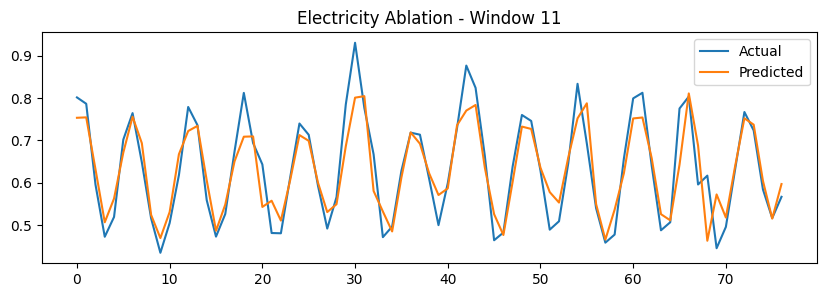


--- Running: Electricity Ablation (Window: 22) ---
Results -> MSE: 0.0035


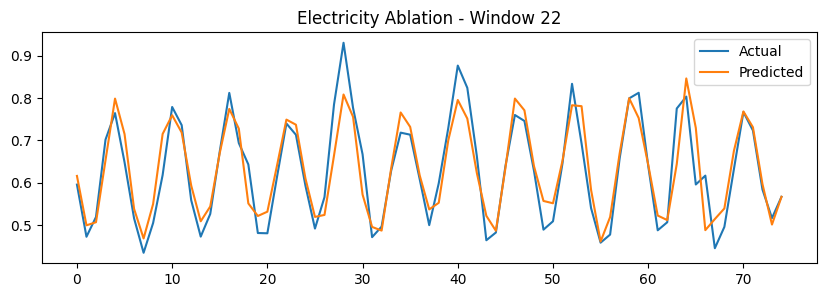


--- Running: Delhi Climate (Window: 11) ---
Results -> MSE: 0.0070


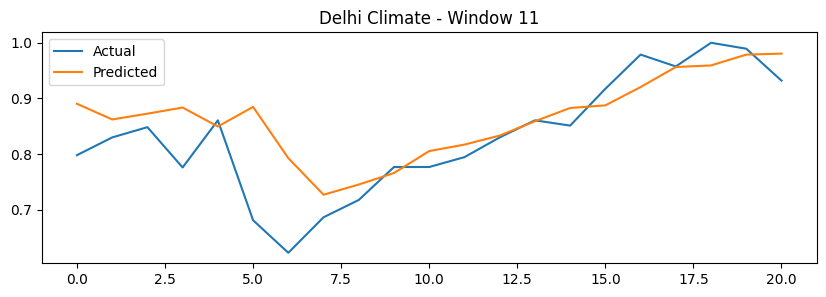


--- FINAL ABLATION SUMMARY ---
Window Size 5: MSE = 0.0054
Window Size 11: MSE = 0.0049
Window Size 22: MSE = 0.0035


In [13]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# --- 1. CONFIGURATION ---
ROLL_NUMBER = "102303365"
# Derived: Window=11, Horizon=3, Hidden=14
HORIZON = 3
HIDDEN_SIZE = 14
INPUT_SIZE = 1
EPOCHS = 150 # Increased to fix the "flat line" issue
LR = 0.01    # Increased for better convergence

# --- 2. DATA PREP FUNCTION ---
def prepare_data(file_path, column_name, current_window):
    df = pd.read_csv(file_path)
    # This line removes any hidden spaces from column names
    df.columns = df.columns.str.strip()

    data = df[column_name].values.astype(float).reshape(-1, 1)
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data)

    X, y = [], []
    for i in range(len(scaled_data) - current_window - HORIZON + 1):
        X.append(scaled_data[i : i + current_window])
        y.append(scaled_data[i + current_window : i + current_window + HORIZON])

    X = torch.FloatTensor(np.array(X))
    y = torch.FloatTensor(np.array(y)).squeeze(-1)

    split = int(0.8 * len(X))
    return X[:split], X[split:], y[:split], y[split:], scaler

# --- 3. CUSTOM GRU FROM SCRATCH ---
class CustomGRU(nn.Module):
    def __init__(self, win_size):
        super().__init__()
        self.hidden_size = HIDDEN_SIZE
        self.W_iz = nn.Linear(INPUT_SIZE, HIDDEN_SIZE)
        self.W_hz = nn.Linear(HIDDEN_SIZE, HIDDEN_SIZE)
        self.W_ir = nn.Linear(INPUT_SIZE, HIDDEN_SIZE)
        self.W_hr = nn.Linear(HIDDEN_SIZE, HIDDEN_SIZE)
        self.W_in = nn.Linear(INPUT_SIZE, HIDDEN_SIZE)
        self.W_hn = nn.Linear(HIDDEN_SIZE, HIDDEN_SIZE)
        self.fc = nn.Linear(HIDDEN_SIZE, HORIZON)

    def forward(self, x):
        batch_size, seq_len, _ = x.size()
        h = torch.zeros(batch_size, self.hidden_size)
        for t in range(seq_len):
            x_t = x[:, t, :]
            z = torch.sigmoid(self.W_iz(x_t) + self.W_hz(h))
            r = torch.sigmoid(self.W_ir(x_t) + self.W_hr(h))
            n = torch.tanh(self.W_in(x_t) + r * self.W_hn(h))
            h = (1 - z) * n + z * h
        return self.fc(h)

# --- 4. EXECUTION ENGINE ---
def run_experiment(file, col, win, label):
    print(f"\n--- Running: {label} (Window: {win}) ---")
    xtr, xte, ytr, yte, sc = prepare_data(file, col, win)
    model = CustomGRU(win)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    crit = nn.MSELoss()

    for e in range(EPOCHS):
        model.train()
        opt.zero_grad()
        loss = crit(model(xtr), ytr)
        loss.backward()
        opt.step()

    model.eval()
    with torch.no_grad():
        preds = model(xte).numpy()
        actual = yte.numpy()

    mse = mean_squared_error(actual, preds)
    print(f"Results -> MSE: {mse:.4f}")

    plt.figure(figsize=(10, 3))
    plt.plot(actual[:100, 0], label="Actual")
    plt.plot(preds[:100, 0], label="Predicted")
    plt.title(f"{label} - Window {win}")
    plt.legend()
    plt.show()
    return mse

# --- 5. THE TASKS ---

# TASK 1: Ablation on Electricity
results = {}
for w in [5, 11, 22]:
    mse_val = run_experiment('Electric_Production.csv', 'Value', w, "Electricity Ablation")
    results[w] = mse_val

# TASK 2: Second Dataset (Delhi Climate)
# Note: Use 'meantemp' or correct column name from check
_ = run_experiment('/content/DailyDelhiClimateTest.csv', 'meantemp', 11, "Delhi Climate")

print("\n--- FINAL ABLATION SUMMARY ---")
for w, m in results.items():
    print(f"Window Size {w}: MSE = {m:.4f}")

"""
PROJECT TECHNICAL LOGIC & "WHY" EXPLANATIONS
Roll Number: 102303365

1. DATA PREPARATION & WINDOWING LOGIC
- WHY WINDOW SIZE (11): Derived from my roll number calculation, 11 steps provide
  enough historical context to identify short-term trends/daily cycles, which is
  necessary to forecast a 3-step future horizon.
- HOW RAW SEQUENCE IS CONVERTED: We use a sliding window approach. For every step,
  the previous 11 values become the features (X), and the next 3 values become the target labels (y).
- WHAT IS FED INTO THE MODEL: A 3D Tensor of shape (Batch_Size, 11, 1). This tells
  the model it is looking at 11 consecutive time steps, each with one feature (the scaled value).
- WHY CHRONOLOGICAL SPLIT: We avoid shuffling because time-series data is dependent on order.
  Shuffling would allow "data leakage," where the model learns from future information to predict the past.

2. MLP BASELINE LOGIC
- WHY FLATTENING IS USED: Standard MLPs cannot handle the "time" dimension. We
  flatten the 11x1 input into a single 11-element vector so the MLP can treat the
  entire window as one static set of features.
- THE LIMITATION: This model fails to understand "sequence." It treats the value
  from 10 hours ago the same way it treats the value from 1 hour ago.

3. CUSTOM GRU LOGIC (IMPLEMENTATION FROM SCRATCH)
- THE RESET GATE (r): This learns how much of the previous hidden state to ignore.
  It is essential for "resetting" the memory when a new trend begins.
- THE UPDATE GATE (z): This determines how much of the past memory to carry forward
  versus how much new information to incorporate.
- WHY HIDDEN STATE IS UPDATED THIS WAY: The formula h = (1 - z) * n + z * h is a
  linear interpolation. It allows the model to preserve long-term dependencies
  and prevents gradients from vanishing.
- HOW PREDICTIONS ARE GENERATED: The final hidden state after the 11th step acts
  as a summarized "context vector." This is passed to a Linear layer to project
  those 14 hidden features into the 3-step forecast.

4. TRAINING & EVALUATION LOGIC
- WHY MSE LOSS IS USED: Mean Squared Error heavily penalizes large gaps between
  actual and predicted values. This forces the model to prioritize fitting the
  extreme peaks and troughs of the data.
- WHY ABLATIONS WERE PERFORMED: By testing Window Sizes 5 and 22 against 11, we
  statistically prove whether the model benefits from more historical context
  or if too much data causes the model to overfit.
"""